### **1 Model Initialization**

#### 1.1 Why Initialization Matters

Model initialization means choosing the starting values of the parameters before training begins.

##### (1) The main problem

During backpropagation, gradients are repeatedly multiplied by weight matrices and activation derivatives. If the scale of these numbers is not controlled, gradients may become:

* too large, causing exploding gradients;
* too small, causing vanishing gradients.

A practical goal is to keep gradient values in a reasonable numeric range, for example roughly between $10^{-6}$ and $10^3$.

##### (2) Common ways to improve stability

Deep learning uses several tools to make training more stable:

* better weight initialization, such as Xavier initialization;
* activation functions that do not shrink gradients too much;
* normalization methods, such as batch normalization or layer normalization;
* gradient clipping, which limits very large gradients;
* architectures such as ResNet or LSTM, which give gradients easier paths through the model.

This note focuses on weight initialization.


### **2 The Goal: Keep Variance Stable**

#### 2.1 Treat Activations and Gradients as Random Variables

A simple way to reason about initialization is to ask whether each layer changes the scale of the signal.

##### (1) Forward pass requirement

For the activation $h_i^t$ of neuron $i$ in layer $t$, we want:

$$
\mathbb{E}[h_i^t] = 0,
\qquad
\operatorname{Var}[h_i^t] = a.
$$

Here $a$ is a constant. The exact value is less important than keeping it from growing or shrinking layer by layer.

##### (2) Backward pass requirement

For the gradient passed through the same layer, we also want:

$$
\mathbb{E}\left[\frac{\partial \ell}{\partial h_i^t}\right] = 0,
\qquad
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_i^t}\right] = b.
$$

Here $b$ is another constant.

##### (3) Intuition

Think of each layer as a volume knob:

* if every layer turns the signal up, values explode;
* if every layer turns the signal down, values vanish;
* good initialization tries to keep the volume about the same.


### **3 Random Weight Initialization**

#### 3.1 Why Not Use Any Small Random Number?

A common old habit is to initialize weights from a small normal distribution such as:

$$
\mathcal{N}(0, 0.01^2).
$$

This can work for small networks, but it is not reliable for deep networks.

##### (1) Why training is fragile at the beginning

At the start of training:

* parameters are far from a good solution;
* the loss surface may be complicated;
* gradients may be unstable;
* a poor initial scale can make the network fail before learning really starts.

Near a good solution, the loss surface is often smoother. But initialization has to get the model into a trainable state first.

##### (2) Visual intuition

The figure below represents the idea that the loss surface can be complicated far away from a good solution.

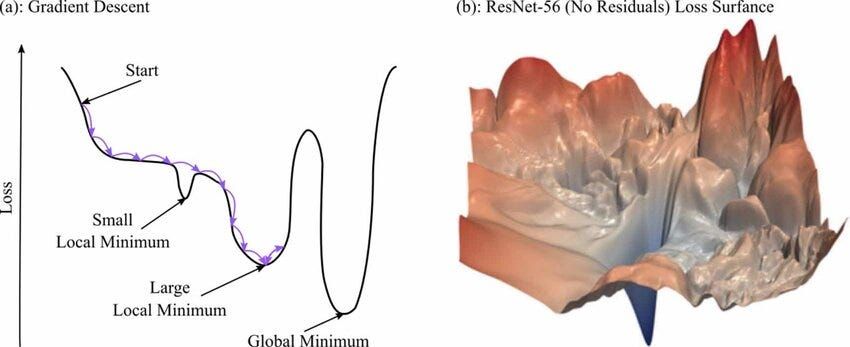


### **4 MLP Example Without Activation**

#### 4.1 Setup

Consider one layer of an MLP without bias and without activation:

$$
\mathbf{h}^t = \mathbf{W}^t\mathbf{h}^{t-1},
\qquad
\mathbf{W}^t \in \mathbb{R}^{n_t \times n_{t-1}}.
$$

Element by element:

$$
h_i^t = \sum_{j=1}^{n_{t-1}} w_{ij}^t h_j^{t-1}.
$$

Assume the weights are independent and identically distributed:

$$
\mathbb{E}[w_{ij}^t] = 0,
\qquad
\operatorname{Var}[w_{ij}^t] = \gamma_t.
$$

Also assume $w_{ij}^t$ is independent of $h_j^{t-1}$.

#### 4.2 Forward Mean

Because the weights have mean zero:

$$
\mathbb{E}[h_i^t]
=
\mathbb{E}\left[\sum_j w_{ij}^t h_j^{t-1}\right]
=
\sum_j \mathbb{E}[w_{ij}^t]\mathbb{E}[h_j^{t-1}]
=
0.
$$

So the output mean stays at zero.


#### 4.3 Forward Variance

Now compute the variance of $h_i^t$.

Because the mean is zero:

$$
\operatorname{Var}[h_i^t]
=
\mathbb{E}[(h_i^t)^2].
$$

Substitute the layer equation:

$$
\operatorname{Var}[h_i^t]
=
\mathbb{E}\left[
\left(\sum_j w_{ij}^t h_j^{t-1}\right)^2
\right].
$$

After expanding the square, cross terms disappear because the weights are independent and have mean zero:

$$
\operatorname{Var}[h_i^t]
=
\sum_j
\mathbb{E}[(w_{ij}^t)^2]
\mathbb{E}[(h_j^{t-1})^2].
$$

Using

$$
\mathbb{E}[(w_{ij}^t)^2] = \gamma_t,
\qquad
\mathbb{E}[(h_j^{t-1})^2] = \operatorname{Var}[h_j^{t-1}],
$$

we get:

$$
\operatorname{Var}[h_i^t]
=
n_{t-1}\gamma_t\operatorname{Var}[h_j^{t-1}].
$$

##### Main conclusion

To keep the forward variance unchanged, we want:

$$
n_{t-1}\gamma_t = 1.
$$

So the weight variance should roughly be:

$$
\gamma_t = \frac{1}{n_{t-1}}.
$$


### **5 Backward Variance**

#### 5.1 Gradient Through the Same Layer

The backward pass has a similar scale problem.

Ignoring activation again, the gradient with respect to the previous layer is obtained by multiplying by the weight matrix:

$$
\frac{\partial \ell}{\partial \mathbf{h}^{t-1}}
=
(\mathbf{W}^t)^T
\frac{\partial \ell}{\partial \mathbf{h}^t}.
$$

For one component, this is a sum over the $n_t$ neurons in the current layer.

#### 5.2 Backward Variance Result

By the same reasoning as the forward pass:

$$
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_i^{t-1}}\right]
=
n_t\gamma_t
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_j^t}\right].
$$

##### Main conclusion

To keep the backward variance unchanged, we want:

$$
n_t\gamma_t = 1.
$$

So the weight variance should roughly be:

$$
\gamma_t = \frac{1}{n_t}.
$$

#### 5.3 The Conflict

The forward pass wants:

$$
\gamma_t = \frac{1}{n_{t-1}}.
$$

The backward pass wants:

$$
\gamma_t = \frac{1}{n_t}.
$$

If $n_{t-1} \ne n_t$, both conditions cannot be exactly true at the same time. Xavier initialization is a compromise between them.


### **6 Xavier Initialization**

#### 6.1 The Compromise

Xavier initialization chooses the weight variance by averaging the forward and backward requirements:

$$
\gamma_t\frac{n_{t-1}+n_t}{2}=1.
$$

Therefore:

$$
\gamma_t = \frac{2}{n_{t-1}+n_t}.
$$

In common terminology:

* $n_{t-1}$ is `fan_in`, the number of inputs to the layer;
* $n_t$ is `fan_out`, the number of outputs from the layer.

So Xavier initialization uses:

$$
\operatorname{Var}[w] = \frac{2}{\text{fan\_in}+\text{fan\_out}}.
$$

#### 6.2 Normal Distribution Version

If weights are sampled from a normal distribution, the variance is set to:

$$
w \sim \mathcal{N}\left(0, \frac{2}{n_{t-1}+n_t}\right).
$$

Equivalently, the standard deviation is:

$$
\sqrt{\frac{2}{n_{t-1}+n_t}}.
$$

#### 6.3 Uniform Distribution Version

For a uniform distribution:

$$
w \sim \mathcal{U}[-a, a].
$$

Since

$$
\operatorname{Var}(\mathcal{U}[-a,a]) = \frac{a^2}{3},
$$

we set:

$$
\frac{a^2}{3} = \frac{2}{n_{t-1}+n_t}.
$$

Therefore:

$$
a = \sqrt{\frac{6}{n_{t-1}+n_t}}.
$$

So the Xavier uniform initialization is:

$$
w \sim
\mathcal{U}\left(
-\sqrt{\frac{6}{n_{t-1}+n_t}},
\sqrt{\frac{6}{n_{t-1}+n_t}}
\right).
$$


### **7 Activation Functions and Initialization**

#### 7.1 Why Activation Functions Matter

The previous derivation ignored activation functions. Real neural networks usually compute:

$$
\mathbf{h}' = \mathbf{W}^t\mathbf{h}^{t-1},
\qquad
\mathbf{h}^t = \sigma(\mathbf{h}').
$$

The activation function can change the mean and variance of the signal.

#### 7.2 Linear Approximation

Near zero, many activation functions can be approximated by a line:

$$
\sigma(x) \approx \alpha x + \beta.
$$

For stable initialization, the ideal case is:

$$
\alpha = 1,
\qquad
\beta = 0.
$$

Why?

* $\beta = 0$ keeps the mean near zero.
* $\alpha = 1$ keeps the variance from being scaled up or down.

#### 7.3 Common Activations Near Zero

Using Taylor expansion:

$$
\operatorname{sigmoid}(x)
=
\frac{1}{2}+\frac{x}{4}-\frac{x^3}{48}+O(x^5),
$$

$$
\tanh(x)
=
x-\frac{x^3}{3}+O(x^5),
$$

$$
\operatorname{ReLU}(x)
=
x \quad \text{for } x \ge 0.
$$

Interpretation:

* sigmoid is not centered at zero and its slope near zero is only $1/4$;
* tanh is centered at zero and has slope $1$ near zero;
* ReLU has slope $1$ on the positive side, but it sets negative values to zero.

This is why Xavier initialization works especially naturally with tanh-like activations. ReLU often uses Kaiming initialization, which adjusts for the fact that roughly half the inputs are set to zero.

#### 7.4 Adjusting Sigmoid

A centered and rescaled sigmoid is:

$$
4\operatorname{sigmoid}(x)-2.
$$

This transformation makes the function closer to $x$ near zero.

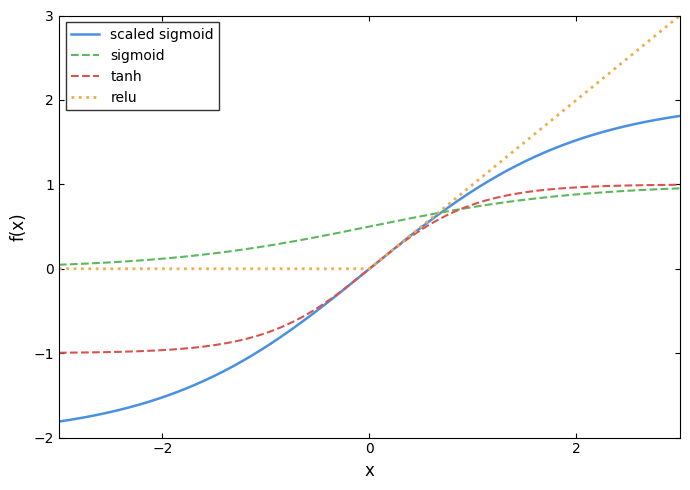


### **8 Simple Explanation**

#### 8.1 The Story in Plain Language

A deep network passes numbers forward and gradients backward through many layers.

Each layer multiplies the signal by weights. If the initial weights are too large, the signal gets amplified again and again. If the initial weights are too small, the signal gets weakened again and again.

Model initialization asks one practical question:

> What scale should the starting weights have so that information neither explodes nor disappears?

#### 8.2 What Xavier Is Doing

For one layer:

* `fan_in` tells how many inputs are added together;
* `fan_out` tells how many gradients are added together when going backward.

More inputs mean more summed terms, so each weight should be smaller. Xavier chooses a variance based on both `fan_in` and `fan_out`:

$$
\operatorname{Var}[w] = \frac{2}{\text{fan\_in}+\text{fan\_out}}.
$$

That is the whole idea: choose the initial weight scale according to the layer shape.

#### 8.3 One Concrete Example

Suppose a layer has:

$$
\text{fan\_in}=100,
\qquad
\text{fan\_out}=50.
$$

Then Xavier uses:

$$
\operatorname{Var}[w]
=
\frac{2}{100+50}
=
\frac{2}{150}
\approx 0.0133.
$$

The standard deviation for the normal version is:

$$
\sqrt{0.0133} \approx 0.115.
$$

So the layer starts with random weights centered at zero, but the spread is chosen carefully from the layer dimensions.


### **9 Summary**

#### 9.1 Key Takeaways

##### (1) Initialization controls signal scale

* Deep networks repeatedly multiply signals by weights.
* Bad initial scale can cause exploding or vanishing activations and gradients.
* Good initialization keeps training numerically stable at the start.

##### (2) Variance is the main quantity

* We want forward activations to keep similar variance across layers.
* We want backward gradients to keep similar variance across layers.
* This leads to conditions on the weight variance.

##### (3) Xavier initialization

For a layer with $n_{t-1}$ inputs and $n_t$ outputs:

$$
\operatorname{Var}[w] = \frac{2}{n_{t-1}+n_t}.
$$

This balances the forward requirement and the backward requirement.

##### (4) Activation functions matter

* Xavier fits best when the activation behaves roughly like the identity function near zero.
* Tanh is close to this near zero.
* Sigmoid is less ideal because it is not zero-centered and has a small slope.
* ReLU often uses Kaiming initialization instead.

#### 9.2 Formula Checklist

##### (1) Forward variance condition

$$
\operatorname{Var}[h_i^t]
=
n_{t-1}\gamma_t\operatorname{Var}[h_j^{t-1}],
\qquad
n_{t-1}\gamma_t = 1.
$$

##### (2) Backward variance condition

$$
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_i^{t-1}}\right]
=
n_t\gamma_t
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_j^t}\right],
\qquad
n_t\gamma_t = 1.
$$

##### (3) Xavier variance

$$
\gamma_t = \frac{2}{n_{t-1}+n_t}.
$$

#### 9.3 One-Sentence Memory Aid

* Xavier initialization chooses the initial weight scale so that signals have roughly the same size when they move forward and backward through the network.
